In [ ]:
import os, random, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# User-editable params
DATA_DIR = "dataset_split"  
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4


TensorFlow: 2.17.0
GPUs: []


In [ ]:
if not os.path.isdir(DATA_DIR):
    print(f"WARNING: DATA_DIR '{DATA_DIR}' not found. Please set DATA_DIR to your dataset path and re-run.")
else:
    classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in classes}
    print("Found classes:", classes)
    print("Counts:", counts)


Found classes: ['test', 'train', 'val']
Counts: {'test': 4, 'train': 4, 'val': 4}


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,       
    brightness_range=[0.8, 1.2],
    channel_shift_range=20,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


In [ ]:
train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "val"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "test"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)


Found 13023 images belonging to 4 classes.
Found 1626 images belonging to 4 classes.
Found 1632 images belonging to 4 classes.


In [ ]:
import numpy as np
y_train = train_gen.classes
classes_list = np.unique(y_train)
class_weights_arr = compute_class_weight(class_weight='balanced', classes=classes_list, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes_list, class_weights_arr)}
print("Class indices:", train_gen.class_indices)
print("Class weights:", class_weights)


Class indices: {'Metal': 0, 'Miscellaneous': 1, 'Paper': 2, 'Plastic': 3}
Class weights: {0: 1.7829956188389924, 1: 0.9199632664594518, 2: 1.4711929507455943, 3: 0.5979338842975207}


In [ ]:
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False

inputs = layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
checkpoint_cb = callbacks.ModelCheckpoint(
    'densenet121_best.keras',  
    save_best_only=True,
    monitor='val_loss',
    mode='min'
)

reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
earlystop = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)


In [ ]:
initial_epochs = 20

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=initial_epochs,
    callbacks=[checkpoint_cb, reduce_lr, earlystop],
    class_weight=class_weights
)


Epoch 1/20


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


407/407 ━━━━━━━━━━━━━━━━━━━━ 458s 1s/step - accuracy: 0.3486 - loss: 1.5343 - val_accuracy: 0.6378 - val_loss: 0.8891 - learning_rate: 1.0000e-04
Epoch 2/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 437s 1s/step - accuracy: 0.5532 - loss: 0.9730 - val_accuracy: 0.6950 - val_loss: 0.7475 - learning_rate: 1.0000e-04
Epoch 3/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 434s 1s/step - accuracy: 0.6031 - loss: 0.8642 - val_accuracy: 0.7159 - val_loss: 0.6995 - learning_rate: 1.0000e-04
Epoch 4/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 436s 1s/step - accuracy: 0.6389 - loss: 0.7825 - val_accuracy: 0.7448 - val_loss: 0.6414 - learning_rate: 1.0000e-04
Epoch 5/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 435s 1s/step - accuracy: 0.6565 - loss: 0.7759 - val_accuracy: 0.7442 - val_loss: 0.6272 - learning_rate: 1.0000e-04
Epoch 6/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 435s 1s/step - accuracy: 0.6699 - loss: 0.7288 - val_accuracy: 0.7515 - val_loss: 0.6185 - learning_rate: 1.0000e-04
Epoch 7/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 437s 1s/step - accuracy: 0.67

In [ ]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 100
for i, layer in enumerate(base_model.layers):
    layer.trainable = i >= fine_tune_at

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_epochs = 20
total_epochs = initial_epochs + fine_epochs

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=total_epochs,
    initial_epoch=initial_epochs,
    callbacks=[checkpoint_cb, reduce_lr, earlystop],
    class_weight=class_weights
)


Epoch 21/40
407/407 ━━━━━━━━━━━━━━━━━━━━ 489s 1s/step - accuracy: 0.6739 - loss: 0.7149 - val_accuracy: 0.8253 - val_loss: 0.4620 - learning_rate: 1.0000e-05
Epoch 22/40
407/407 ━━━━━━━━━━━━━━━━━━━━ 462s 1s/step - accuracy: 0.7291 - loss: 0.6002 - val_accuracy: 0.8376 - val_loss: 0.4250 - learning_rate: 1.0000e-05
Epoch 23/40
407/407 ━━━━━━━━━━━━━━━━━━━━ 469s 1s/step - accuracy: 0.7439 - loss: 0.5555 - val_accuracy: 0.8499 - val_loss: 0.4006 - learning_rate: 1.0000e-05
Epoch 24/40
407/407 ━━━━━━━━━━━━━━━━━━━━ 470s 1s/step - accuracy: 0.7726 - loss: 0.4984 - val_accuracy: 0.8579 - val_loss: 0.3817 - learning_rate: 1.0000e-05
Epoch 25/40
407/407 ━━━━━━━━━━━━━━━━━━━━ 471s 1s/step - accuracy: 0.7830 - loss: 0.4806 - val_accuracy: 0.8647 - val_loss: 0.3607 - learning_rate: 1.0000e-05
Epoch 26/40
407/407 ━━━━━━━━━━━━━━━━━━━━ 471s 1s/step - accuracy: 0.7987 - loss: 0.4457 - val_accuracy: 0.8739 - val_loss: 0.3361 - learning_rate: 1.0000e-05
Epoch 27/40
407/407 ━━━━━━━━━━━━━━━━━━━━ 476s 1s/ste

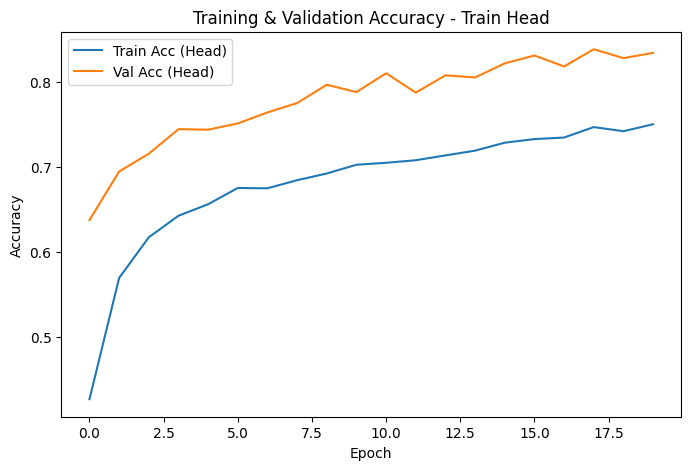

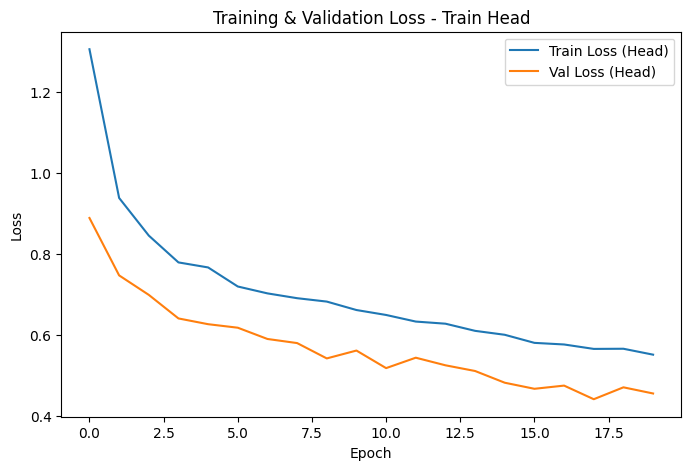

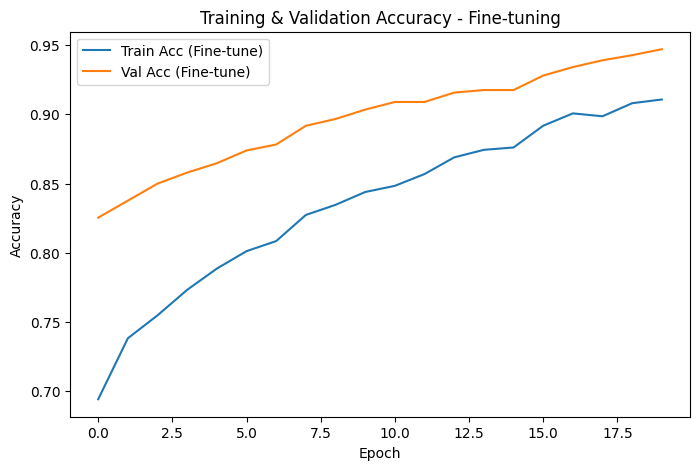

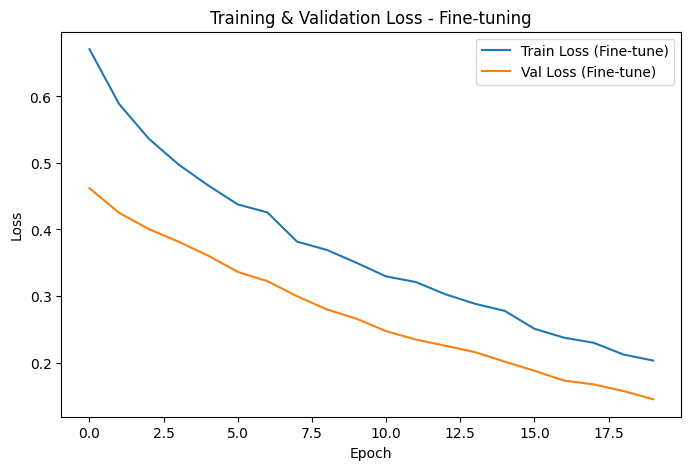

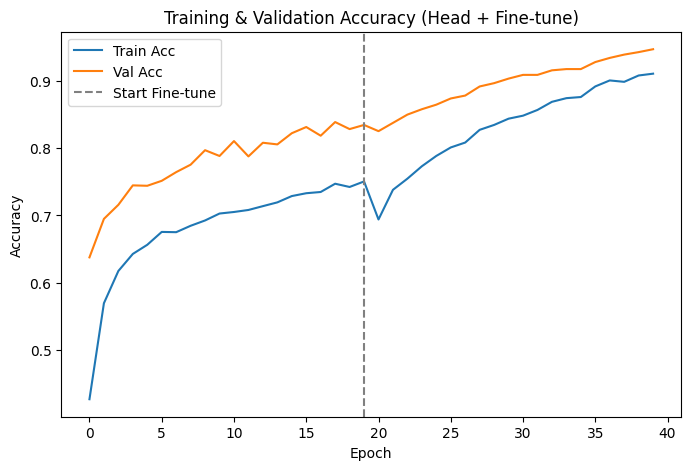

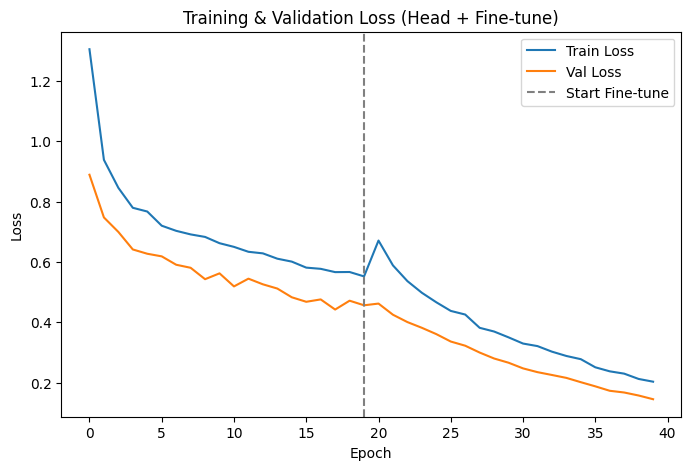

In [17]:
import matplotlib.pyplot as plt

# ================================
# 📌 1️⃣ GIAI ĐOẠN TRAIN HEAD
# ================================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Acc (Head)')
plt.plot(history.history['val_accuracy'], label='Val Acc (Head)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy - Train Head')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss (Head)')
plt.plot(history.history['val_loss'], label='Val Loss (Head)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss - Train Head')
plt.legend()
plt.show()


# ================================
# 📌 2️⃣ GIAI ĐOẠN FINE-TUNE
# ================================
plt.figure(figsize=(8,5))
plt.plot(history_fine.history['accuracy'], label='Train Acc (Fine-tune)')
plt.plot(history_fine.history['val_accuracy'], label='Val Acc (Fine-tune)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy - Fine-tuning')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_fine.history['loss'], label='Train Loss (Fine-tune)')
plt.plot(history_fine.history['val_loss'], label='Val Loss (Fine-tune)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss - Fine-tuning')
plt.legend()
plt.show()


# ================================
# 📌 3️⃣ COMBINED (HEAD + FINE-TUNE)
# ================================
# Nối lịch sử lại
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.axvline(x=len(history.history['accuracy'])-1, color='gray', linestyle='--', label='Start Fine-tune')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy (Head + Fine-tune)')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=len(history.history['loss'])-1, color='gray', linestyle='--', label='Start Fine-tune')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss (Head + Fine-tune)')
plt.legend()
plt.show()


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


51/51 ━━━━━━━━━━━━━━━━━━━━ 47s 923ms/step - accuracy: 0.9643 - loss: 0.1004
Test loss: 0.1447, Test accuracy: 0.9473
51/51 ━━━━━━━━━━━━━━━━━━━━ 48s 889ms/step

Accuracy: 0.9473
Precision: 0.9497
Recall: 0.9473
F1-score: 0.9473


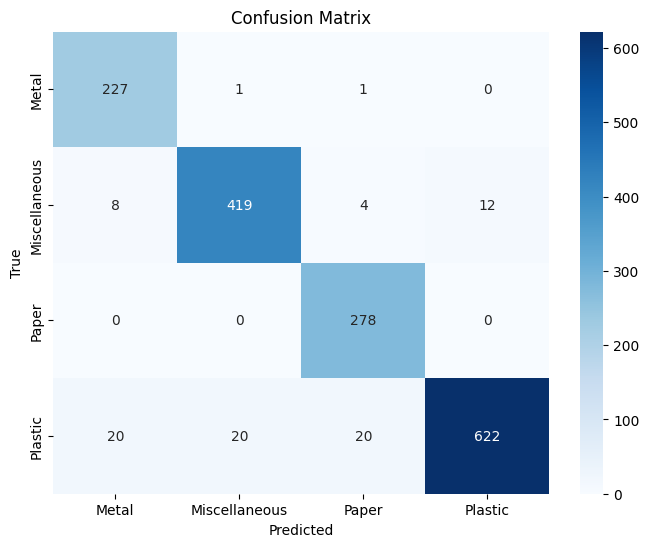


Classification Report:
               precision    recall  f1-score   support

        Metal       0.89      0.99      0.94       229
Miscellaneous       0.95      0.95      0.95       443
        Paper       0.92      1.00      0.96       278
      Plastic       0.98      0.91      0.95       682

     accuracy                           0.95      1632
    macro avg       0.94      0.96      0.95      1632
 weighted avg       0.95      0.95      0.95      1632



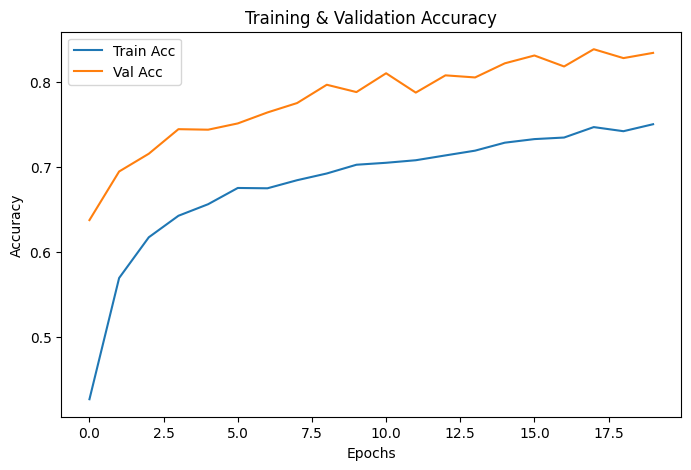

In [ ]:
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

# Evaluate loss & accuracy
loss, acc = model.evaluate(test_gen)
print(f"Test loss: {loss:.4f}, Test accuracy: {acc:.4f}")

# Predict on test set
test_gen.reset()
preds = model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes
class_names = list(train_gen.class_indices.keys())

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Confusion matrix (visual)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot training curves
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')
plt.show()


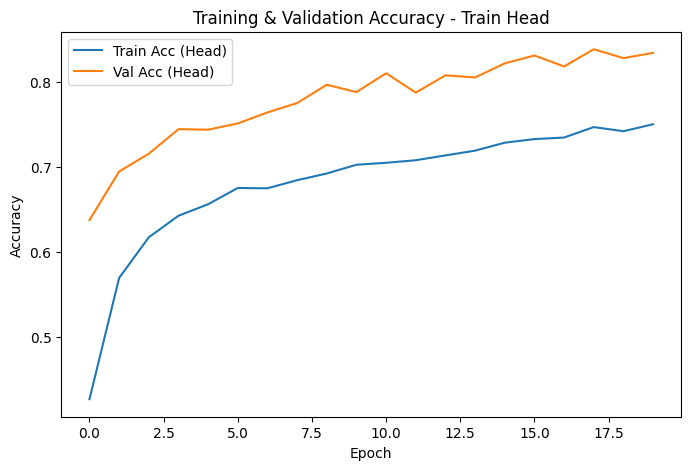

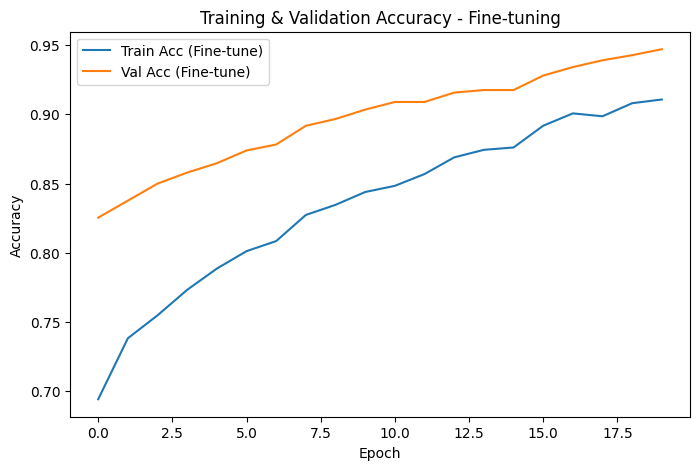

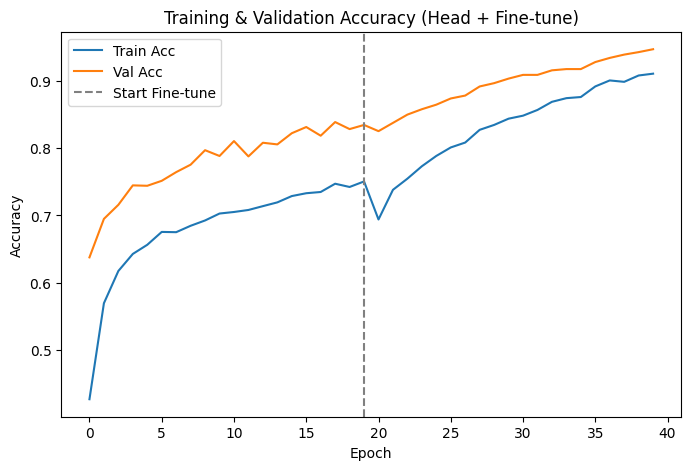

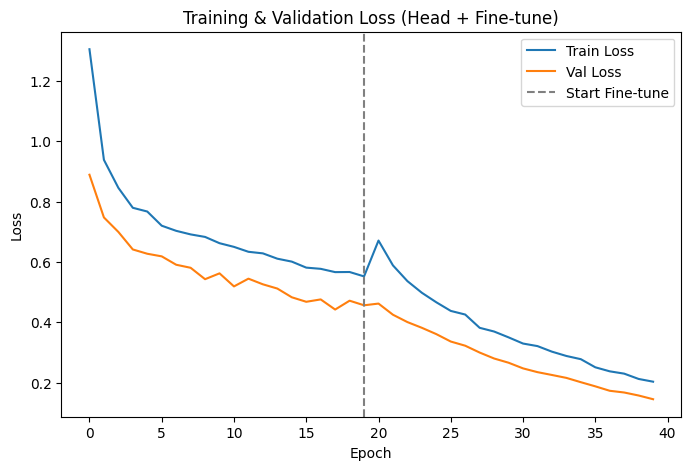

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Acc (Head)')
plt.plot(history.history['val_accuracy'], label='Val Acc (Head)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy - Train Head')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_fine.history['accuracy'], label='Train Acc (Fine-tune)')
plt.plot(history_fine.history['val_accuracy'], label='Val Acc (Fine-tune)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy - Fine-tuning')
plt.legend()
plt.show()

# Nối lịch sử lại
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.axvline(x=len(history.history['accuracy'])-1, color='gray', linestyle='--', label='Start Fine-tune')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy (Head + Fine-tune)')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=len(history.history['loss'])-1, color='gray', linestyle='--', label='Start Fine-tune')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss (Head + Fine-tune)')
plt.legend()
plt.show()


In [13]:
import os

# Tạo folder 'model_version' nếu chưa có
os.makedirs("model_version", exist_ok=True)

# Lưu model vào folder đó
model.save("model_version/densenet121_v3.keras")

print("✅ Saved model to model_version/densenet121_v3.keras")


✅ Saved model to model_version/densenet121_v3.keras


In [14]:
import tensorflow as tf
import gc

# 🧹 1️⃣ Xóa biến model khỏi Python
del model
del base_model

# 🧼 2️⃣ Gom rác của Python
gc.collect()

# 🔄 3️⃣ Xóa session TensorFlow (xóa graph, weights, optimizer cache)
tf.keras.backend.clear_session()

# ⚡️ 4️⃣ (Tuỳ chọn) Giải phóng GPU nếu có
# tf.config.experimental.reset_memory_stats('GPU:0')

print("✅ Model cleared from RAM and TensorFlow session reset.")



✅ Model cleared from RAM and TensorFlow session reset.


In [15]:
from pathlib import Path
import os

# Xác định thư mục Keras cache hiện tại
keras_cache = os.environ.get('KERAS_HOME')  # nếu có biến môi trường
if not keras_cache:
    keras_cache = Path.home() / "AppData" / "Roaming" / "Keras" / "datasets"

print("Keras datasets cache folder:", keras_cache)


Keras datasets cache folder: C:\Users\LENOVO\AppData\Roaming\Keras\datasets


In [16]:
from pathlib import Path

keras_models_cache = Path.home() / "AppData" / "Roaming" / "Keras" / "models"

if not keras_models_cache.exists():
    print("⚠️ Keras models cache folder not found:", keras_models_cache)
else:
    print("Files in Keras models cache:")
    for f in keras_models_cache.iterdir():
        print(f.name)
        # Xóa file DenseNet121 nếu tên file chứa 'densenet121'
        if "densenet121" in f.name.lower():
            f.unlink()
            print(f"✅ Deleted cached file: {f.name}")


⚠️ Keras models cache folder not found: C:\Users\LENOVO\AppData\Roaming\Keras\models
